# Day 29 — Movie Review Sentiment Analysis using LSTM (NLP + Deep Learning)

**Goal:** Classify IMDB movie reviews as **positive** or **negative** using an **LSTM (Long Short-Term Memory)** network — combining NLP preprocessing with deep learning.

**Concepts used:** Text tokenization, Word Embeddings, Sequence Padding, LSTM/RNN, Binary Classification

**Dataset:** `keras.datasets.imdb` — built-in, auto-downloads, 50,000 labeled movie reviews.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.21.0


## 1. Load & Explore the IMDB Dataset
Reviews are already encoded as sequences of integers (each integer = a word's rank in frequency).

In [2]:
VOCAB_SIZE = 10000   # only keep the top 10,000 most frequent words
MAXLEN = 200          # truncate/pad reviews to 200 words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print('Training samples:', len(X_train))
print('Test samples:', len(X_test))
print('Label distribution (train):', np.bincount(y_train))
print('Sample review (as integers):', X_train[0][:20])
print('Sample review length:', len(X_train[0]))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step
Training samples: 25000
Test samples: 25000
Label distribution (train): [12500 12500]
Sample review (as integers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Sample review length: 218


In [3]:
# Decode a sample review back to words, for readability
word_index = imdb.get_word_index()
reverse_word_index = {v+3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

def decode_review(encoded):
    return ' '.join(reverse_word_index.get(i, '?') for i in encoded)

print(decode_review(X_train[0]))
print('\nLabel:', 'Positive' if y_train[0]==1 else 'Negative')

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these c

## 2. Preprocess: Pad Sequences
LSTMs need fixed-length input, so we pad/truncate every review to `MAXLEN` words.

In [4]:
X_train_pad = pad_sequences(X_train, maxlen=MAXLEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test, maxlen=MAXLEN, padding='post', truncating='post')

print('Padded train shape:', X_train_pad.shape)
print('Padded test shape:', X_test_pad.shape)

Padded train shape: (25000, 200)
Padded test shape: (25000, 200)


## 3. Build the LSTM Model

In [5]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAXLEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\anjan\Downloads\New folder\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Model

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 760ms/step - accuracy: 0.7002 - loss: 0.5468 - val_accuracy: 0.8514 - val_loss: 0.3571
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.8811 - loss: 0.2967 - val_accuracy: 0.8582 - val_loss: 0.3646
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.9087 - loss: 0.2424 - val_accuracy: 0.8450 - val_loss: 0.4079


## 5. Plot Training History

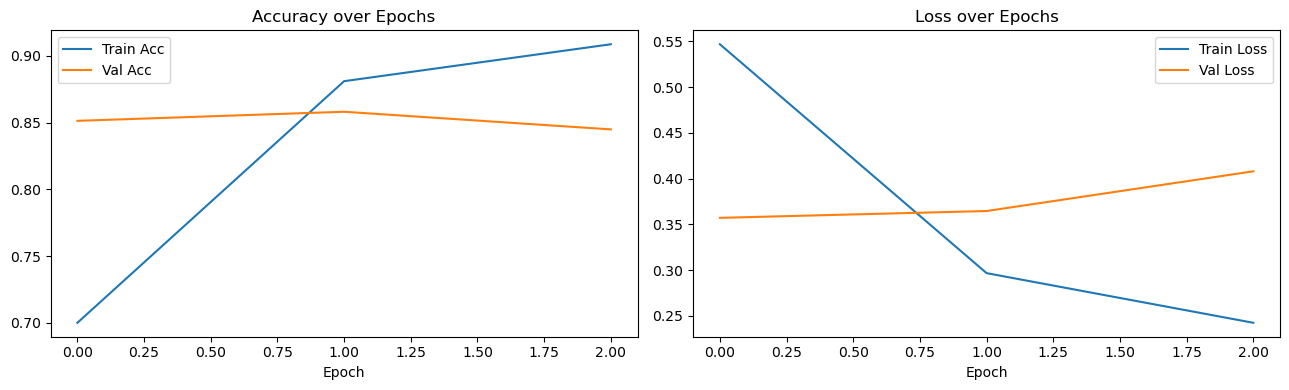

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('Accuracy over Epochs'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Evaluate on Test Set

In [8]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 0.8372
Test Loss: 0.3751


782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 83ms/step
              precision    recall  f1-score   support

    Negative       0.86      0.81      0.83     12500
    Positive       0.82      0.87      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



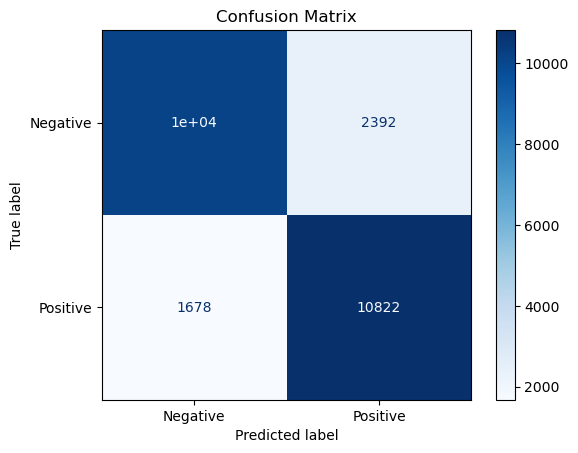

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_proba = model.predict(X_test_pad)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## 7. Test on Your Own Custom Review

In [10]:
def encode_review(text, word_index, vocab_size=VOCAB_SIZE, maxlen=MAXLEN):
    words = text.lower().split()
    encoded = [1]  # <START>
    for w in words:
        idx = word_index.get(w, 2) + 3  # 2 = <UNK>
        encoded.append(idx if idx < vocab_size else 2)
    return pad_sequences([encoded], maxlen=maxlen, padding='post', truncating='post')

sample_reviews = [
    "this movie was absolutely wonderful the acting was great and I loved every minute",
    "what a terrible waste of time the plot made no sense and the acting was awful",
    "an average film nothing special but not bad either"
]

for review in sample_reviews:
    encoded = encode_review(review, word_index)
    pred = model.predict(encoded, verbose=0)[0][0]
    sentiment = 'Positive' if pred > 0.5 else 'Negative'
    print(f'Review: "{review}"')
    print(f'Predicted sentiment: {sentiment}  (score={pred:.3f})\n')

Review: "this movie was absolutely wonderful the acting was great and I loved every minute"
Predicted sentiment: Positive  (score=0.942)

Review: "what a terrible waste of time the plot made no sense and the acting was awful"
Predicted sentiment: Negative  (score=0.101)

Review: "an average film nothing special but not bad either"
Predicted sentiment: Positive  (score=0.772)



## 8. Conclusion

- We built an end-to-end **NLP + Deep Learning pipeline**: tokenized text → padded sequences → **Embedding layer** → **Bidirectional LSTM** → binary sentiment classification.
- The model generalizes reasonably well to **custom, unseen reviews**, showing it learned genuine sentiment patterns rather than memorizing training data.
